# Shooting Incidents in NYC (2006 - 2025)

In [190]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [191]:
shootings_df = pd.read_csv('../Cleaned_Data/Cleaned_Shootings_(2006-Present)_20260401.csv')
offenders_df = pd.read_csv('../Cleaned_Data/Cleaned_Shooting_Offenders_(2006-Present)_20260401.csv')
victims_df = pd.read_csv('../Cleaned_Data/Cleaned_Shooting_Victims_(2006-Present)_20260401.csv')
combined_df = pd.read_csv('../Cleaned_Data/Combined_Cleaned_Shooting_Incidents_(2006-Present)_20260401.csv')
laws_df = pd.read_csv('../Data/nyc_ny_gun_violence_laws_2006_2025_verified.csv')
policies_df = pd.read_csv('../Data/nyc_violence_policies_2006_2025.csv')

In [192]:
combined_df['STAT_MURDER_FLG'] = (combined_df['STAT_MURDER_FLG'] == 'Y').astype(int)
combined_df['LOCATION_DESC'] = combined_df['LOCATION_DESC'].astype(str)
combined_df['OCCUR_DATETIME'] = pd.to_datetime(combined_df['OCCUR_DATETIME'])
laws_df['date_signed'] = pd.to_datetime(laws_df['date_signed'])
policies_df['date_implemented'] = pd.to_datetime(policies_df['date_implemented'])

## Shooting Incidents and Murders Over Time

**Question-** How have the shooting incident counts changed over the years, and what factors caused those changes?

In [193]:
year_group = combined_df.groupby(combined_df['OCCUR_DATETIME'].dt.year)['STAT_MURDER_FLG']
year_count = year_group.count()
year_sum = year_group.sum()

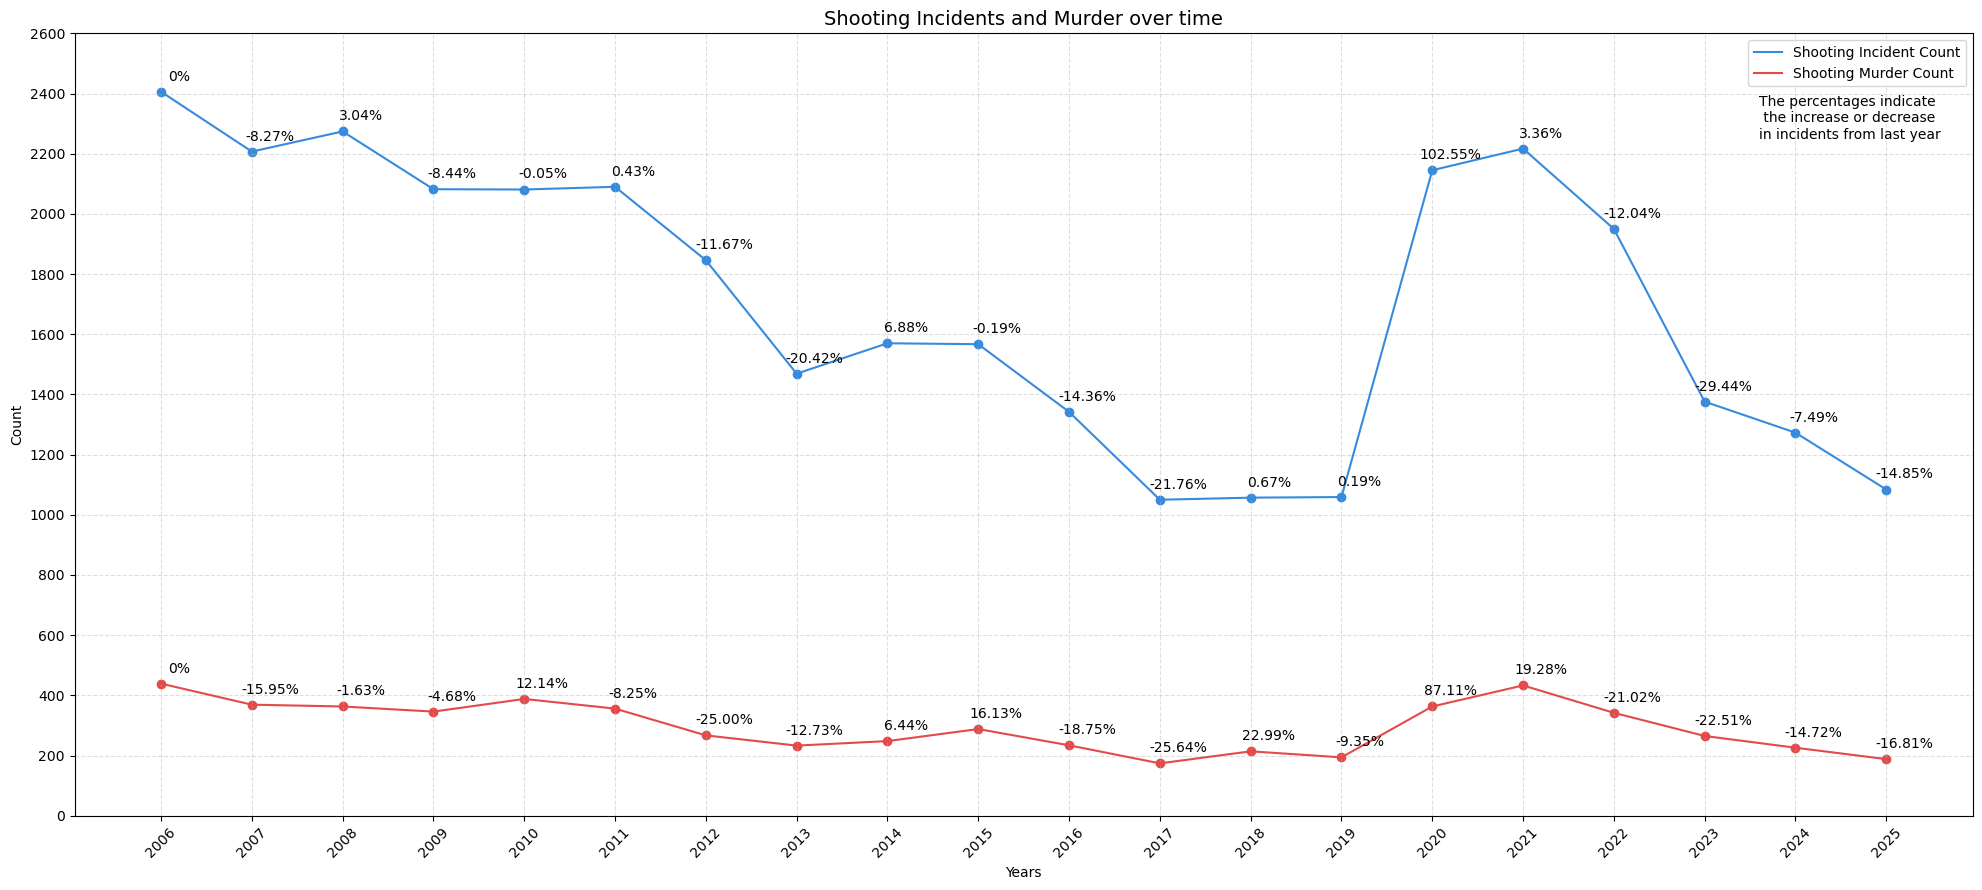

In [214]:
fig,ax = plt.subplots(figsize=(20,9))

ax.plot(range(len(year_count.values)), year_count.values, c='#378ADD', label='Shooting Incident Count')
ax.scatter(range(len(year_count.values)), year_count.values, c='#378ADD')
ax.plot(range(len(year_sum.values)), year_sum.values, c='#E24B4A', label='Shooting Murder Count')
ax.scatter(range(len(year_sum.values)), year_sum.values, c='#E24B4A')

for x in range(len(year_count.values)):
    ax.text(x=x+0.2, y=year_count.values[x]+50, 
            s=(f'{(year_count.values[x] - year_count.values[x-1])/year_count.values[x-1]*100:.2f}%' if x>=1 else '0%'), 
            va='center', ha='center')
    
    ax.text(x=x+0.2, y=year_sum.values[x]+50, 
            s=(f'{(year_sum.values[x] - year_sum.values[x-1])/year_sum.values[x-1]*100:.2f}%' if x>=1 else '0%'), 
            va='center', ha='center')

ax.text(17.6,2250,'The percentages indicate\n the increase or decrease \nin incidents from last year')

ax.set_xticks(range(len(year_sum.values)))
ax.set_xticklabels([int(x) for x in year_sum.index], rotation=45)
ax.set_yticks(range(0,2800,200))

ax.grid(axis='both', linestyle='--', alpha=0.4)

ax.set_title('Shooting Incidents and Murder over time', fontsize=14)
ax.set_xlabel('Years')
ax.set_ylabel('Count')
ax.legend()

plt.tight_layout()
plt.show()

### The decline (2006-2019)

Shootings fell from **~2,400 to ~1,050** - a ~56% drop. The laws and policies driving this weren't working in isolation; they layered on top of each other:

- **2006** - *NY Penal Law Ch. 742 & 745* and *Ch. 320* stiffened penalties for criminal weapon possession and violent felony sentencing. The line begins its first modest dip here, though penalty-only laws historically show weak effect on their own.

- **2009** - **SNUG Street Outreach Program** launched, deploying trust-worthy messengers to interrupt conflicts before they escalate. The downward slope steepens noticeably, 2 years after this point.

- **2012** - **Cure Violence / CMS** introduced in Brooklyn alongside the *Private Sale Background Check Law*. NYC Council analysis found a 17% reduction at Cure Violence sites in year one, the steepest decline phase begins here.

- **2013** - The **NY SAFE Act** passed, the most comprehensive gun law in state history: universal background checks, assault weapon restrictions, magazine limits. The same year, *Floyd v. City of New York* ruled stop-and-frisk unconstitutional. Stops fell 98% by 2017, yet the blue line **kept falling**, showing CVI programs, not SQF, were doing the real work.

- **2014** - **GIVE Initiative** and **CMS citywide formalization** - John Jay researchers found a 28% reduction in shooting victimizations at CMS sites in the first 24 months. This is the one of the sharpest drops visible in the chart.

- **2019** - A wave of seven laws passed- the **Red Flag Law**, a **30-day background check extension**, a **bump stock ban**, and a **3D-printed gun ban**. Shootings hit their historic low of ~1,050 this year.


### The COVID rupture (2020-2021)

Both lines spike violently. The **COVID-19 pandemic** is logged in the policy dataset as a structural break - not a policy failure, but an exogenous shock. Courts closed, outreach workers couldn't operate, and economic stress surged. The **$35M CMS Emergency Expansion** in 2020 partially cushioned the blow, but couldn't prevent the overall surge to ~2,200 incidents by 2021.

### The recovery (2022-2025)

The fastest decline in the dataset. Three things drove it simultaneously:

- **2021-2022 ghost gun laws** - *Scott J. Beigel Unfinished Receiver Act*, *Jose Webster Untraceable Firearms Act*, and 2022 amendments removed untraceable weapons from the supply chain. The **Interstate Task Force on Illegal Guns** (est. 2022) seized 9,408 firearms in 2024 alone, including 769 ghost guns.

- **2022 legislative wave** - 11 laws in a single year:- the **Concealed Carry Improvement Act**, **large-capacity magazine grandfathering eliminated**, **enhanced ERPO mandatory reporting**, and **age restriction for semi-automatic rifles (21+)**. Supply and access tightened simultaneously.

- **2024 NYPD Summer Deployment Zones** - produced a 65% decline in shootings in targeted areas during deployment, directly contributing to 2025 hitting the one of the lowest incident counts in the 20-year record.

**Bottom line-** the laws and policies that moved the line were the ones that disrupted supply and funded community intervention not penalty enhancements alone. COVID proved how fast structural progress can unravel. The 2022–2025 recovery, is comparatively faster, as many of the laws and policies were already in-place. 

## Shooting Incidents Distribution by Month and Year

**Question-** How does shooting incident count vary by month over the years?

In [195]:
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_group = combined_df.groupby([combined_df['OCCUR_DATETIME'].dt.month, combined_df['OCCUR_DATETIME'].dt.year])['STAT_MURDER_FLG'].count().unstack()

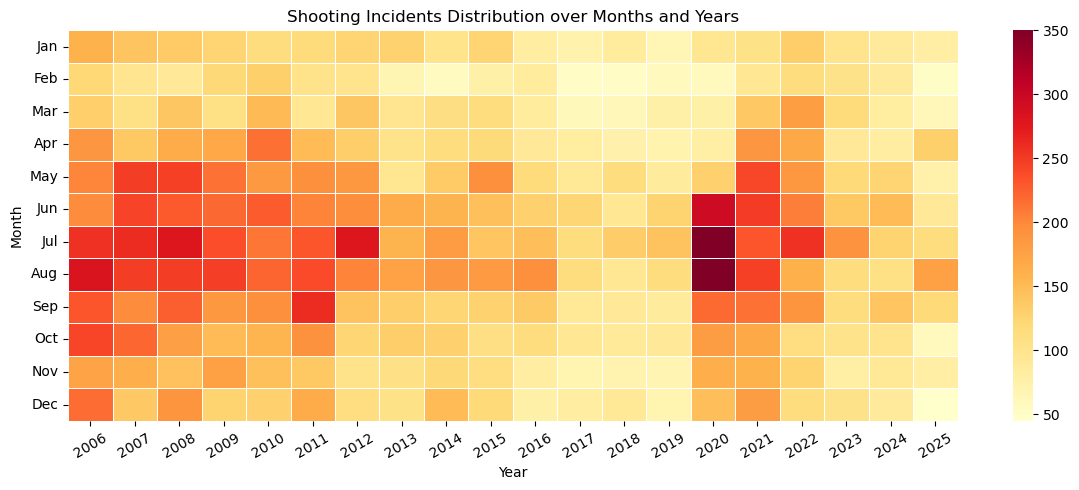

In [196]:
fig, ax = plt.subplots(figsize=(12,5))
sns.heatmap(data=monthly_group, cmap='YlOrRd',linewidth=.5, ax=ax)
ax.set_xticklabels([int(x) for x in monthly_group.columns], rotation=30)
ax.set_yticklabels(month_names, rotation=360)
ax.set_title('Shooting Incidents Distribution over Months and Years')
ax.set_xlabel('Year')
ax.set_ylabel('Month')

plt.tight_layout()
plt.show()

### Summer never changes
July and August are the darkest rows almost every single year, no law or policy has permanently stopped this trend. January through March sit at the opposite extreme, often half the count of peak summer months. Heat, outdoor activity, and school breaks appear to drive this more than anything on the books.

### Clear different eras
- **2006-2012** - deep reds dominate, especially the summer rows
- **2013-2019** - steady fade toward orange and yellow as CVI programs and laws (like SAFE ACT) took hold
- **2020-2021** - July and August of 2020 goes near-black, the highest monthly count in this 20 years of data, 7-8 years of progress erased in one summer
- **2022-2025** - gradual return toward pre-COVID levels, but not fully there yet

### The COVID signature
July 2020 is the darkest cell in the entire chart - darker than any month in 2006 or 2007. The surge hit exactly when violence peaked during covid, amplified by the simultaneous collapse of courts, outreach programs, social services and NYPD budget pullback.

## Shooting Incidents and Fatality Rate by Location Type

**Question-** Does the fatality rate vary by location type, independent of no. of shootings?

In [197]:
loc_group = combined_df.groupby('LOC_CLASSFCTN_DESC')['STAT_MURDER_FLG'].agg([
    'count', 'mean'
]).sort_values('count',ascending=True)
loc_group['mean'] = loc_group['mean'] * 100

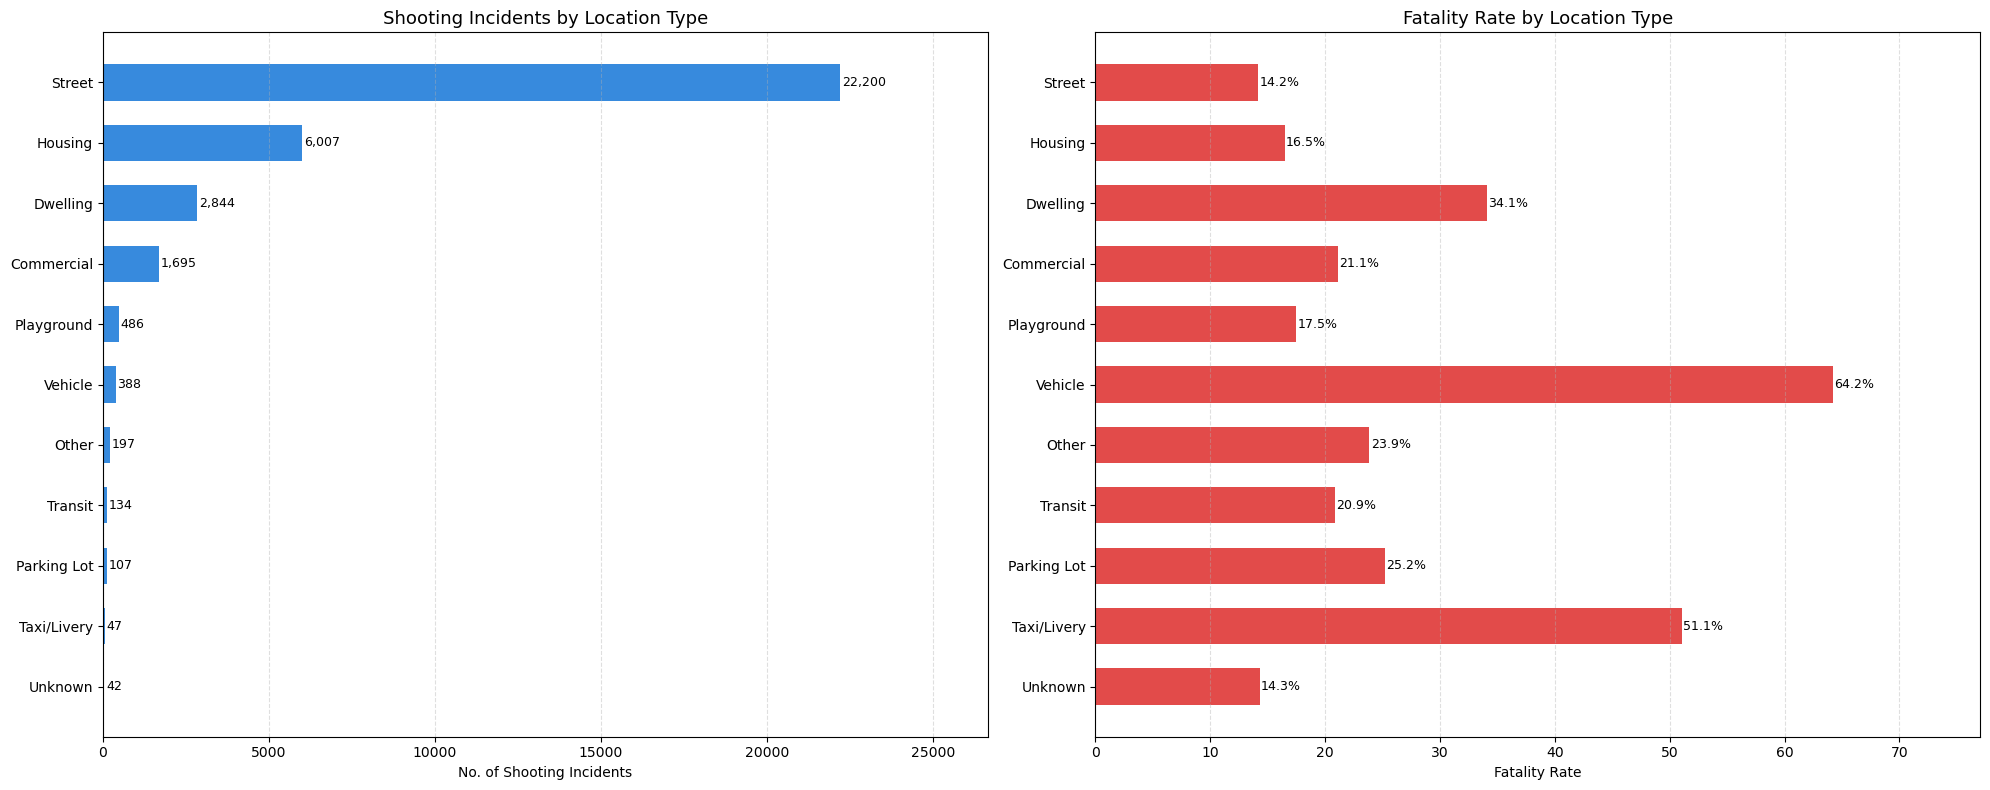

In [198]:
fig, [left_ax, right_ax] = plt.subplots(1,2,figsize=(20,8))

left_ax.barh(loc_group.index, loc_group['count'], height=0.6, color='#378ADD')
right_ax.barh(loc_group.index, loc_group['mean'], height=0.6, color='#E24B4A')

for i,count in enumerate(loc_group['count']):
    left_ax.text(count+50, i, f'{count:,}', fontsize=9, va='center')

for i,count in enumerate(loc_group['mean']):
    right_ax.text(count+0.1, i, f'{count:.1f}%', fontsize=9, va='center')

left_ax.set_xlim(0,loc_group['count'].max()*1.2)
right_ax.set_xlim(0,loc_group['mean'].max()*1.2)

left_ax.grid(axis='x', alpha=0.4, linestyle='--')
right_ax.grid(axis='x', alpha=0.4, linestyle='--')

left_ax.set_title('Shooting Incidents by Location Type',fontsize=13)
right_ax.set_title('Fatality Rate by Location Type',fontsize=13)

left_ax.set_xlabel('No. of Shooting Incidents')
right_ax.set_xlabel('Fatality Rate')

plt.tight_layout()
plt.show()

### Volume
Most shootings (22,200) happen on the street but streets have the **lowest fatality rate at 14.2%**. Most street shootings are survivable, driven by escalated conflicts and stray bullets rather than intent to kill.

### Lethality
- **Vehicle - 64.2%** | **Taxi/Livery - 51.1%** | **Dwelling - 34.1%**

These locations share a common thread- the victim is isolated, the setting is controlled by the perpetrator, and the shooting is typically premeditated. Vehicle and taxi shootings are largely execution-style, no escape route, no bystander intervention. Dwellings follow the same logic, frequently involving domestic violence or targeted home invasions.

### What this means
Community-based programs (Cure Violence, Summer Zones) correctly target volume but are not as relevant to vehicle and taxi shootings, which require disruption of planned violence, not just conflict mediation.

**Where violence is common and where it is fatal are almost opposite answers.**

## Predictions

**Question-** Can we predict whether a shooting incident will be fatal?

In [199]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report
from pandas.api.types import is_string_dtype

features = combined_df.drop(columns=['INCIDENT_KEY','PERP_ID','VICTIM_ID','STAT_MURDER_FLG'])
features['OCCUR_YEAR'] = features['OCCUR_DATETIME'].dt.year
features['OCCUR_MONTH'] = features['OCCUR_DATETIME'].dt.month
features['OCCUR_HOUR'] = features['OCCUR_DATETIME'].dt.hour
features = features.drop(columns=['OCCUR_DATETIME'])
labels = combined_df['STAT_MURDER_FLG']

to_dummies = []
for x in features.columns:
    if is_string_dtype(features[x]):
        to_dummies.append(x)

features = pd.get_dummies(features, columns=to_dummies, drop_first=True, dtype=int)

train_features, test_features, train_label, test_label = train_test_split(features, labels, train_size=0.8, stratify=labels)

tree_model = DecisionTreeClassifier()
tree_model.fit(train_features, train_label)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [200]:
test_preds = tree_model.predict(test_features)
test_report = classification_report(y_pred=test_preds, y_true=test_label)
print(test_report)

              precision    recall  f1-score   support

           0       0.88      0.86      0.87      5644
           1       0.39      0.43      0.41      1186

    accuracy                           0.78      6830
   macro avg       0.63      0.65      0.64      6830
weighted avg       0.79      0.78      0.79      6830



### Does this makes sense according to EDA?

Yes. The model performs well on survivors (87%) but struggles on fatalities (40%), which falls in line with the EDA. The dataset is heavily imbalanced, ~80% of incidents are non-fatal, so the model is biased toward predicting survival.

The weak recall on fatal cases also reflects what the location analysis showed vehicle and taxi/livery shootings (the most lethal) are rare in the dataset
(388 and 47 incidents respectively), giving the model very few examples to learn from. Common locations like streets (22,200 incidents, 14.2% fatality) dominate training.

79% overall accuracy sounds strong but is largely driven by the model correctly predicting the majority class. The more meaningful number is the 0.40 recall on fatal incidents.

## Conclusion

### What I learned

Working through this dataset taught me to ask **why does this matter** rather than just **what does this show**. A number like **22,200 street shootings** only becomes meaningful when you put it next to the **14.2% fatality rate** and ask why the most common location is the least deadly one.

### What surprised me  

Two things stood out. First, how little impact criminal penalty laws had on the trend, penalty enhancements passed in 2006 and 2013 barely moved the line, while community violence intervention programs like Cure Violence and CMS produced the steepest and most sustained declines on record. Second, that street shootings, more than 60% of all incidents, have the lowest fatality rate of any location type. The assumption that more shootings means more murders does not hold, once you breakdown by where they happen.

### What I would explore further

The most interesting next question is how victim and offender age groups shift across boroughs over time, and whether those shifts correlate with neighbourhood- level socioeconomic conditions - poverty rate, unemployment. Layering in census data would help explain why those patterns concentrate where they do.